In [ ]:
# Run this cell to ensure CatBoost is installed in your Colab environment
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00:00:0100:01m


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore')

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ==========================================
# 1. DATA LOADING & ALIGNMENT
# ==========================================
# The training data covers January to November 2026, while the test data covers December 2026[cite: 1')
train = pd.read_csv('/content/drive/MyDrive/datafest/train.csv')
test = pd.read_csv('/content/drive/MyDrive/datafest/test.csv')

# Preserve the exact original row order of the test set for the final submission requirement[cite: 1].
test['original_order'] = range(len(test))
test['objetivo'] = np.nan

df = pd.concat([train, test], ignore_index=True)

In [11]:
df.head(10)

,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo,original_order
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,...,False,222,10,9.898223,android,21,True,67,0.0,NaN
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,...,False,58,2,9.311922,ios,20,True,304,0.0,NaN
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,...,False,8,6,12.188249,android,12,False,220,0.0,NaN
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,...,False,119,9,10.459796,ios,20,False,110,0.0,NaN
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,...,False,25,6,36.502645,ios,13,False,247,1.0,NaN
5,6,202601,68,51533.870421,0.245293,57,2,25085.696636,40,professional,...,True,234,8,7.151985,web,7,False,40,1.0,NaN
6,7,202601,26,68519.815499,0.175526,135,1,33288.859454,269,manual,...,True,179,9,6.483404,android,5,False,269,0.0,NaN
7,8,202601,33,38186.112671,0.120406,78,4,17769.119633,46,clerical,...,True,125,5,8.869183,otro,9,False,46,0.0,NaN
8,9,202601,64,91528.779660,0.394170,4,3,63587.713330,106,clerical,...,False,99,6,5.503591,android,6,False,106,0.0,NaN
9,10,202601,63,62055.894781,0.122771,77,2,28642.298570,216,clerical,...,True,129,5,3.034573,web,2,False,216,0.0,NaN


In [13]:
df.tail(10)

,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,...,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo,original_order
119990,26458,202612,44,78336.023770,0.464526,124,2,36710.693773,130,professional,...,True,201,9,10.981276,ios,18,False,204,NaN,9890.0
119991,26459,202612,64,89828.585414,0.086052,133,3,38955.601612,267,clerical,...,False,125,6,3.228481,ios,12,False,141,NaN,9891.0
119992,26460,202612,48,47652.252736,0.103667,87,1,21264.945486,160,professional,...,False,123,10,4.943257,android,12,False,2,NaN,9892.0
119993,26461,202612,52,57920.957920,0.287826,69,4,35625.202640,20,manual,...,False,234,4,7.288376,android,5,True,358,NaN,9893.0
119994,26462,202612,22,64206.578244,0.622420,117,1,9426.243848,110,professional,...,False,221,7,6.669713,android,9,False,311,NaN,9894.0
119995,26463,202612,58,55048.139550,0.299626,35,4,20374.168372,263,manual,...,False,146,7,12.348168,web,20,False,218,NaN,9895.0
119996,26464,202612,51,46659.481481,0.511840,87,1,36129.188137,136,professional,...,True,211,11,9.888910,android,18,False,178,NaN,9896.0
119997,26465,202612,52,74961.776694,0.376967,1,2,12637.928481,325,manual,...,True,161,7,21.200152,otro,8,False,132,NaN,9897.0
119998,26466,202612,30,47722.172114,0.277668,82,3,300.000000,45,professional,...,True,183,12,10.426281,ios,10,True,197,NaN,9898.0
119999,26467,202612,32,42732.725586,0.519541,151,3,3885.447063,69,professional,...,False,87,7,4.200502,ios,8,False,23,NaN,9899.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

print("Información del dataset:\\n")
train.info()

print("\\nValores nulos por columna:\\n", train.isnull().sum())
print("\\nEstadísticas descriptivas (Numéricas):\\n", train.describe())


Información del dataset:\n
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110100 entries, 0 to 110099
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   110100 non-null  int64  
 1   mes                          110100 non-null  int64  
 2   edad                         110100 non-null  int64  
 3   ingresos                     110100 non-null  float64
 4   ratio_deuda_ingresos         110100 non-null  float64
 5   antiguedad_cuenta_meses      110100 non-null  int64  
 6   numero_productos             110100 non-null  int64  
 7   saldo_promedio               110100 non-null  float64
 8   dias_ultima_transaccion      110100 non-null  int64  
 9   ocupacion                    110100 non-null  object 
 10  region                       110100 non-null  object 
 11  canal_adquisicion            110100 non-null  object 
 12  banda_riesgo                 11

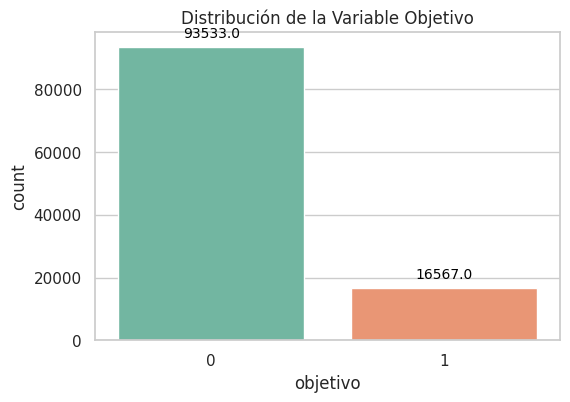

Proporción de clases:\n objetivo
0    0.849528
1    0.150472
Name: proportion, dtype: float64


In [15]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=train, x='objetivo', palette='Set2')
plt.title('Distribución de la Variable Objetivo')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

print("Proporción de clases:\\n", train['objetivo'].value_counts(normalize=True))


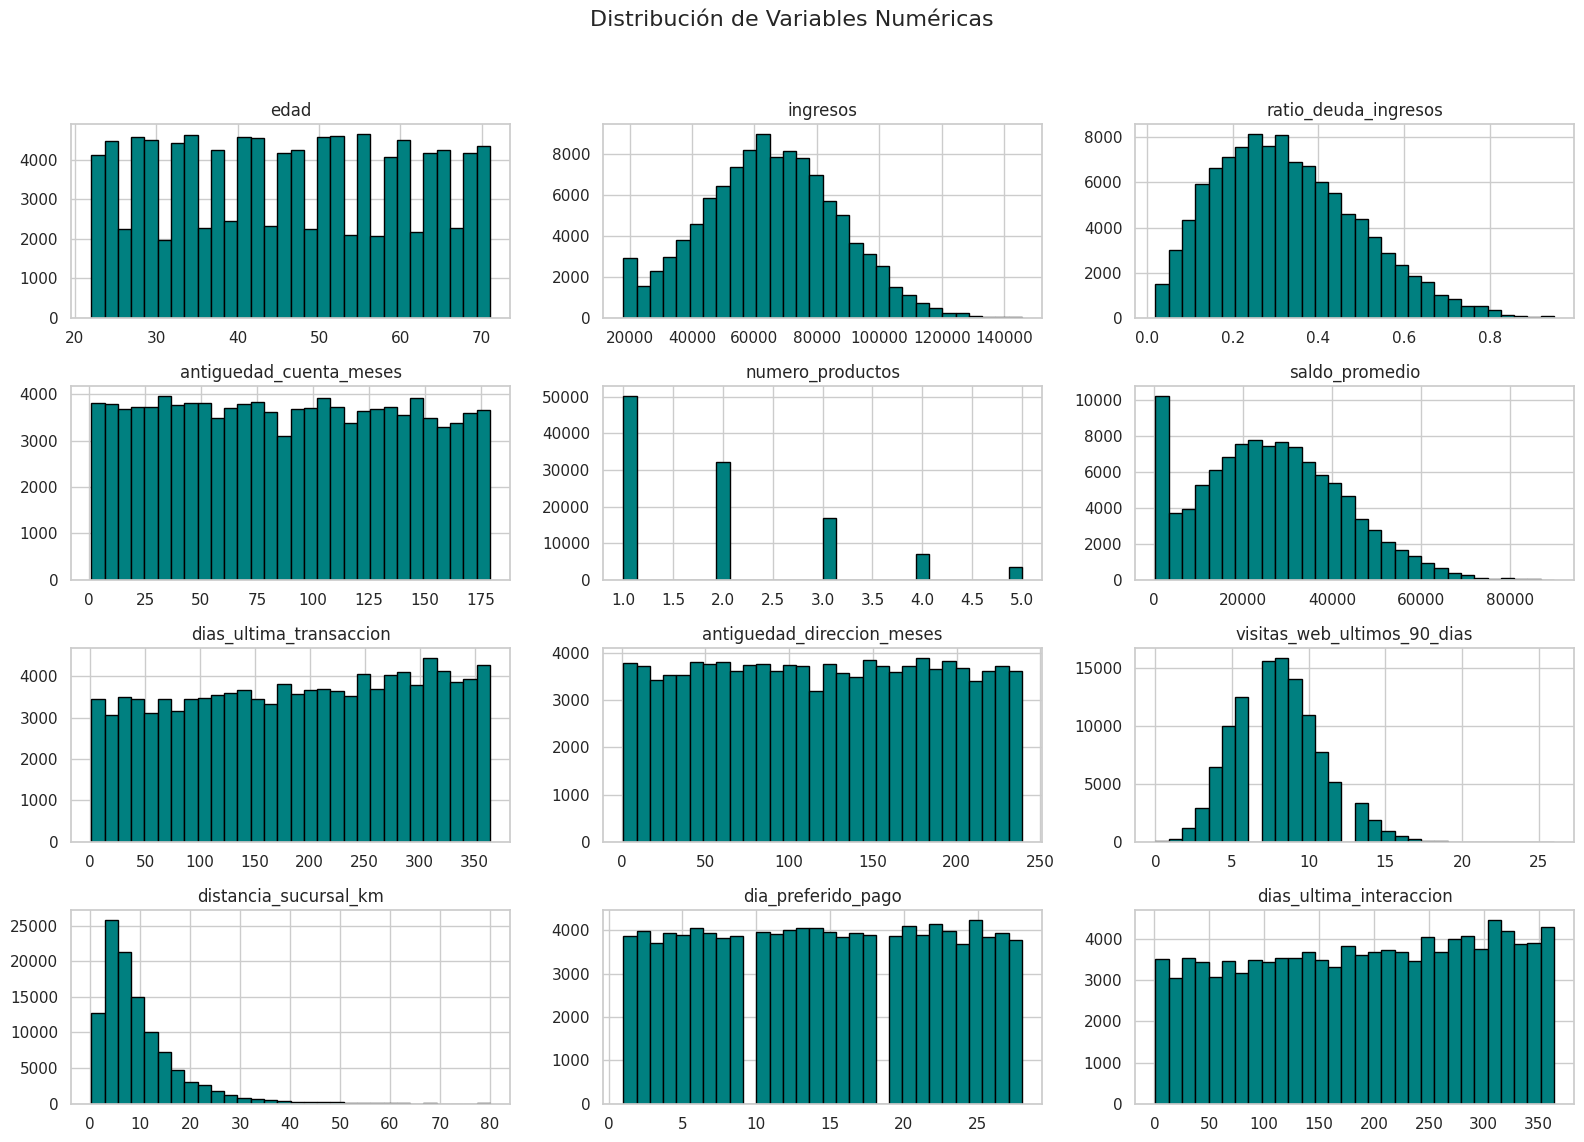

In [16]:
num_vars = ['edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 
            'numero_productos', 'saldo_promedio', 'dias_ultima_transaccion', 
            'antiguedad_direccion_meses', 'visitas_web_ultimos_90_dias', 
            'distancia_sucursal_km', 'dia_preferido_pago', 'dias_ultima_interaccion']

train[num_vars].hist(bins=30, figsize=(16, 12), color='teal', edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


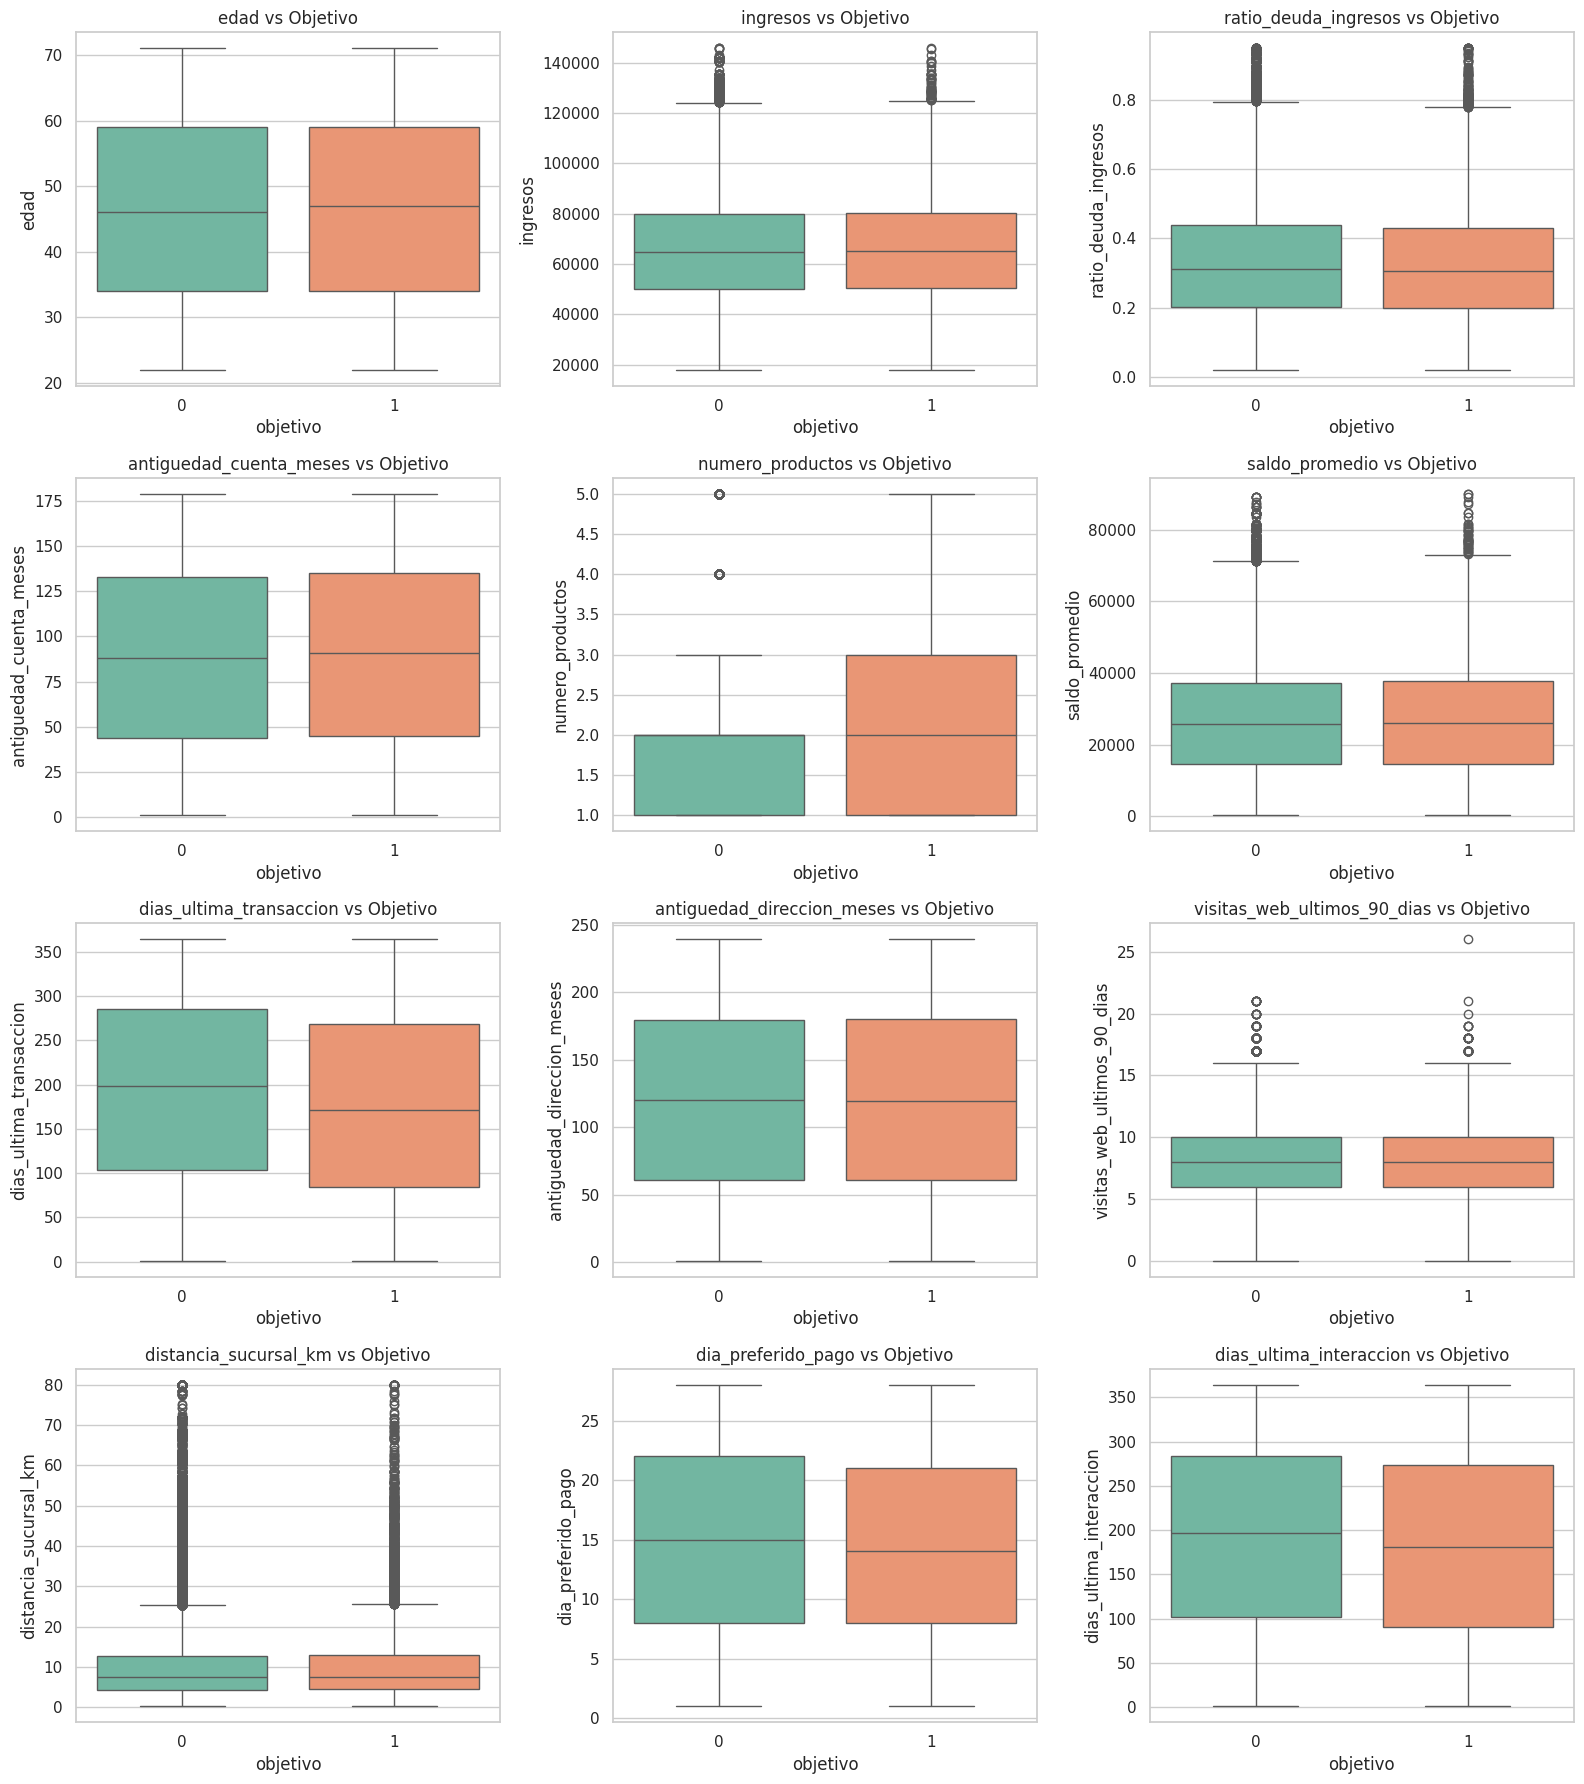

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    sns.boxplot(x='objetivo', y=col, data=train, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Objetivo')

plt.tight_layout()
plt.show()


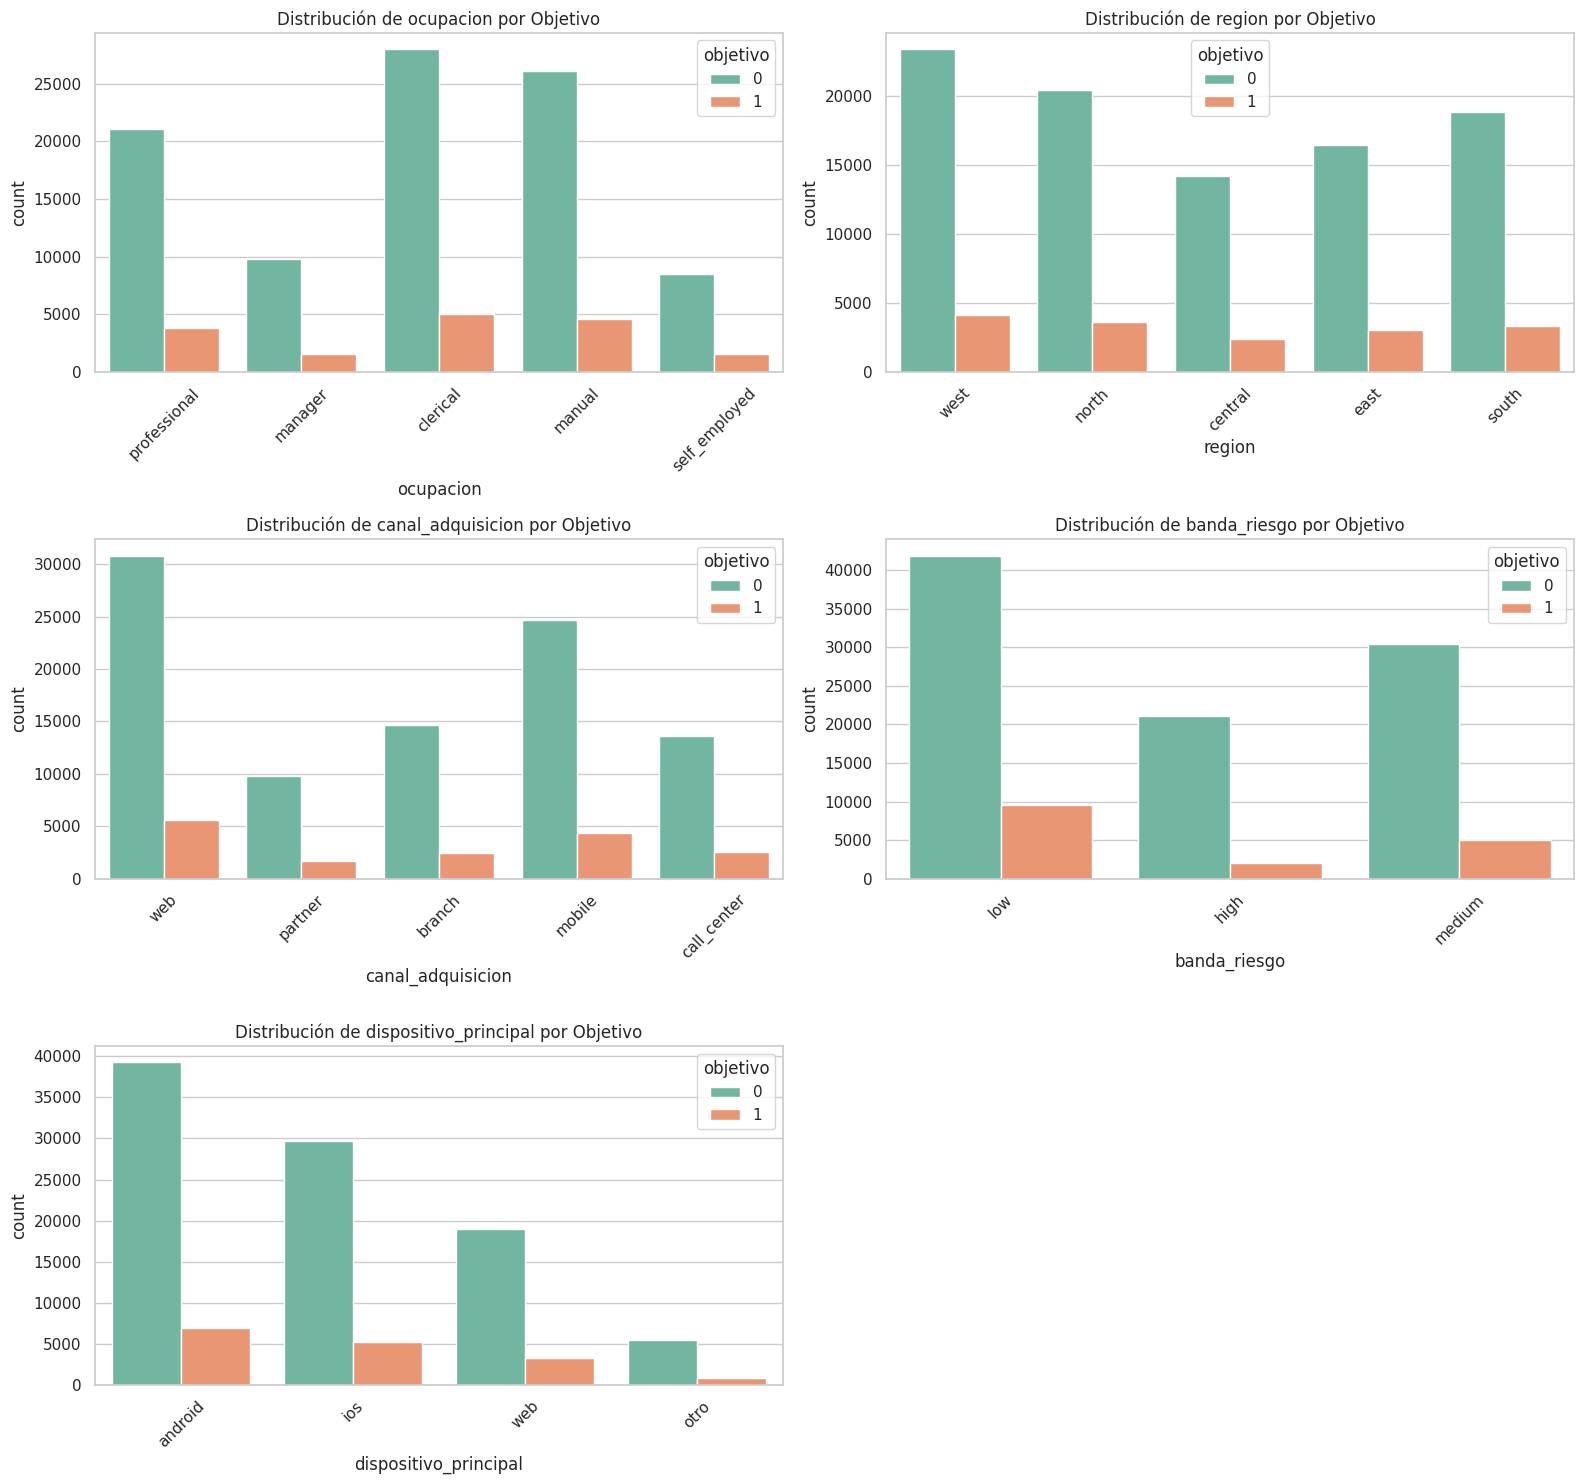

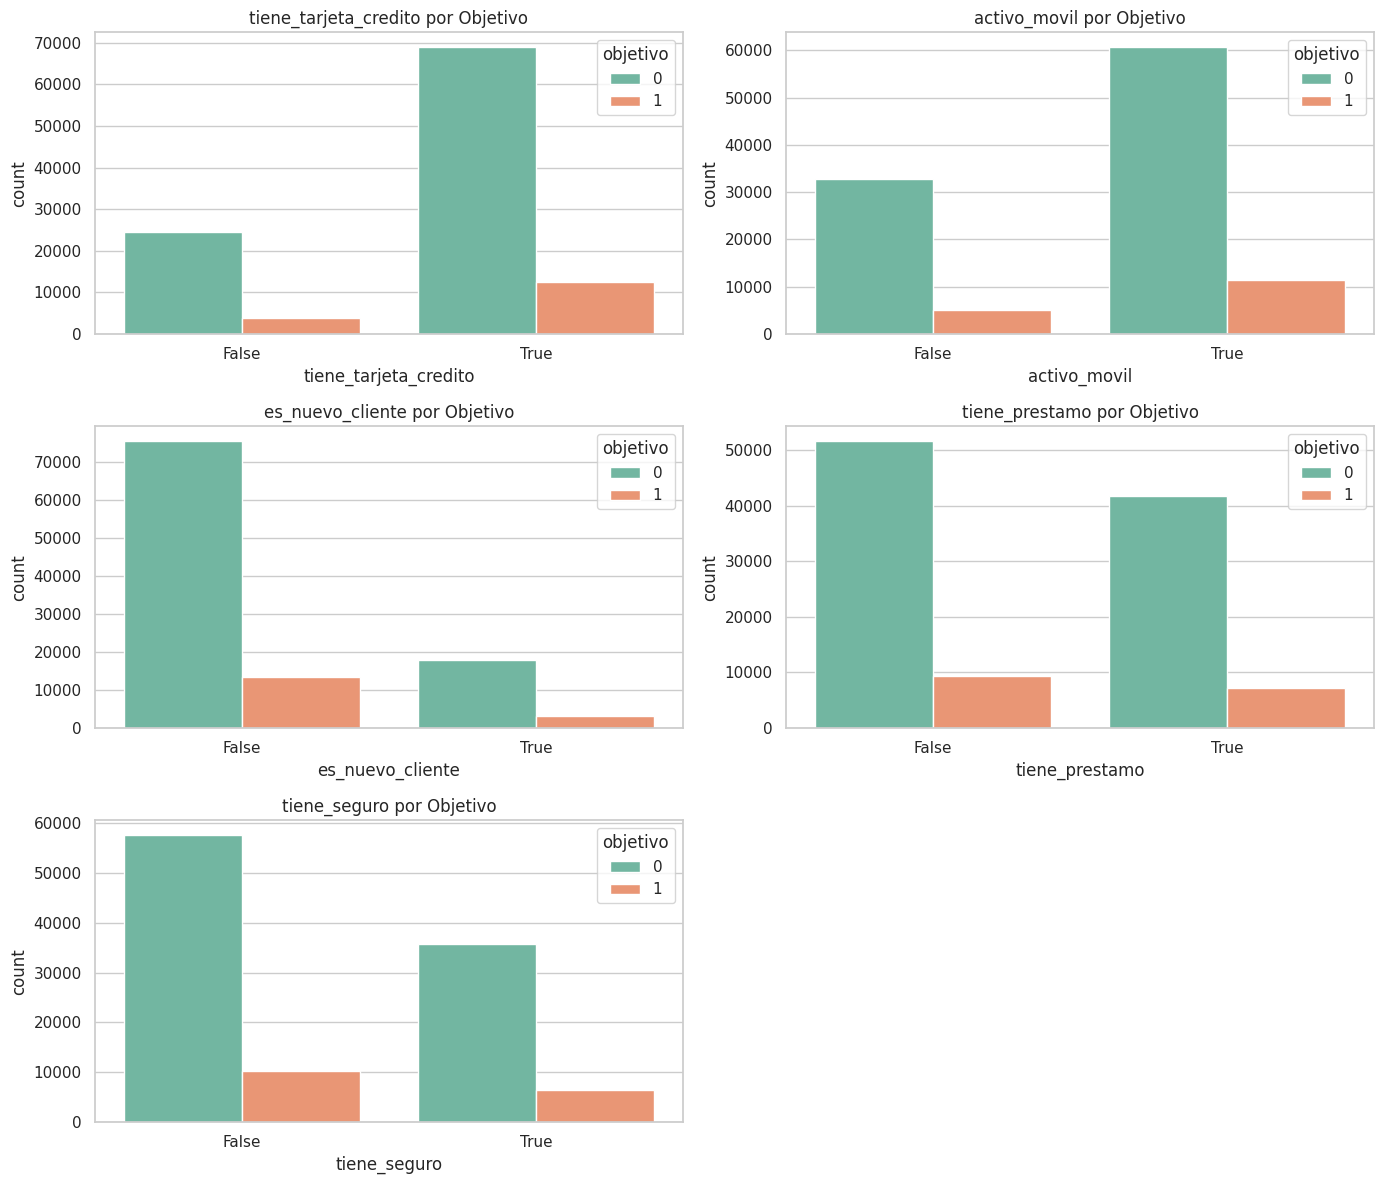

In [18]:
cat_vars = ['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']
bool_vars = ['tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'tiene_seguro']

# Graficar variables categóricas
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()
for i, col in enumerate(cat_vars):
    sns.countplot(x=col, hue='objetivo', data=train, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col} por Objetivo')
    axes[i].tick_params(axis='x', rotation=45)
fig.delaxes(axes[-1]) # Eliminar el último gráfico vacío
plt.tight_layout()
plt.show()

# Graficar variables booleanas
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(bool_vars):
    sns.countplot(x=col, hue='objetivo', data=train, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} por Objetivo')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


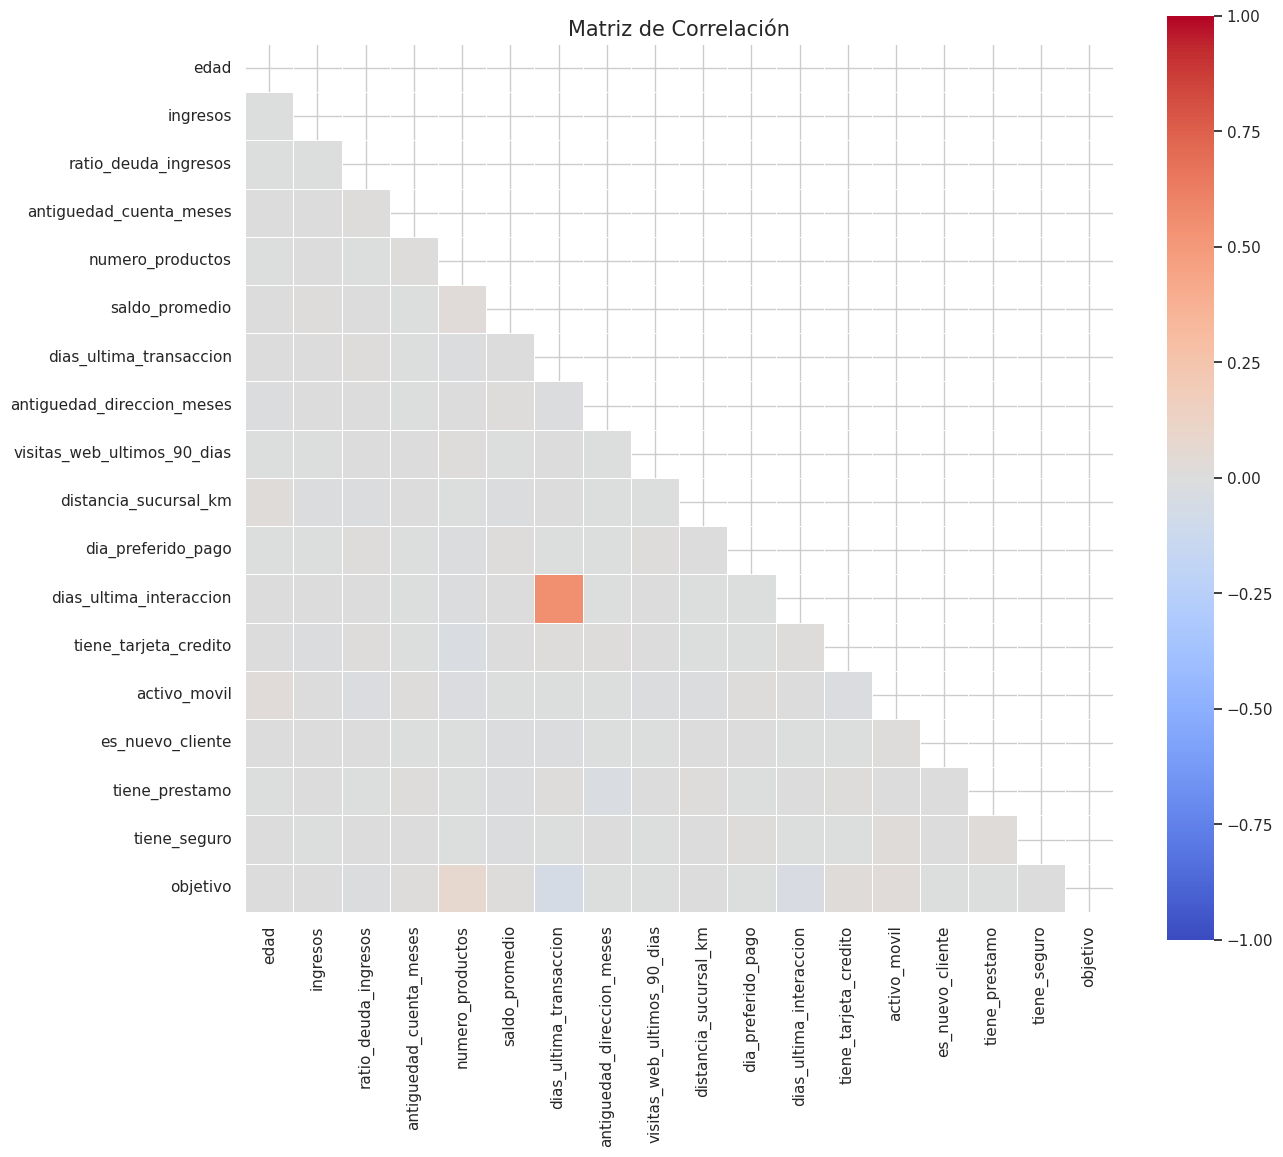

In [21]:
plt.figure(figsize=(14, 12))
# Seleccionamos variables numéricas y booleanas
#vars_corr = num_vars + bool_vars + ['objetivo']
#corr_matrix = train[vars_corr].corr()
# Cambiamos el método a 'spearman' para ignorar el efecto de cualquier posible outlier
corr_matrix = train[num_vars + bool_vars + ['objetivo']].corr(method='spearman')

# Máscara para la mitad superior
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=15)
plt.show()


In [22]:

# ==========================================
# 2. PANEL DATA FEATURE ENGINEERING
# ==========================================
# Sort chronologically by client and month to safely calculate historical states without future leakage[cite: 1].
df = df.sort_values(by=['id_cliente', 'mes']).reset_index(drop=True)

# Aggregate all boolean flags into a single activity density metric[cite: 1].
bool_cols = ['tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'tiene_seguro']
df['total_productos_activos'] = df[bool_cols].sum(axis=1)

# Generate Lag (T-1) and Velocity (Delta) features for key numeric variables[cite: 1].
lag_features = ['saldo_promedio', 'ratio_deuda_ingresos', 'dias_ultima_transaccion']
for col in lag_features:
    df[f'{col}_lag1'] = df.groupby('id_cliente')[col].shift(1)
    df[f'{col}_delta1'] = df[col] - df[f'{col}_lag1']

# Calculate behavioral cross-feature friction[cite: 1].
df['friccion_interaccion'] = df['dias_ultima_interaccion'] - df['dias_ultima_transaccion']

# Format categorical variables for native handling by GBDT algorithms[cite: 1].
cat_cols = ['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']
for col in cat_cols:
    df[col] = df[col].astype(str).astype('category')

# ==========================================
# 3. OUT-OF-TIME (OOT) VALIDATION SPLIT
# ==========================================
train_df = df[df['objetivo'].notna()].copy()
test_df  = df[df['objetivo'].isna()].copy()

# Validate strictly on November 2026 data to mimic the test set distribution shift[cite: 1].
X_train = train_df[train_df['mes'] < 202611]
y_train = X_train['objetivo']

X_val = train_df[train_df['mes'] == 202611]
y_val = X_val['objetivo']

# Drop identifiers and targets from the active training feature space[cite: 1].
drop_cols = ['id_cliente', 'mes', 'objetivo', 'original_order']
features = [c for c in train_df.columns if c not in drop_cols]


In [23]:
# ==========================================
# 4. LIGHTGBM MODEL TRAINING
# ==========================================
print("Training LightGBM...")
lgb_train = lgb.Dataset(X_train[features], label=y_train)
lgb_val = lgb.Dataset(X_val[features], label=y_val, reference=lgb_train)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'verbose': -1
}

model_lgb = lgb.train(
    lgb_params,
    lgb_train,
    valid_sets=[lgb_train, lgb_val],
    num_boost_round=1500,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)

# ==========================================
# 5. CATBOOST MODEL TRAINING
# ==========================================
print("\nTraining CatBoost...")
model_cat = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.05,
    eval_metric='AUC',
    cat_features=cat_cols,
    random_seed=42,
    verbose=0
)

model_cat.fit(
    X_train[features], y_train,
    eval_set=(X_val[features], y_val),
    early_stopping_rounds=50
)

# ==========================================
# 6. ENSEMBLE & GINI EVALUATION
# ==========================================
val_preds_lgb = model_lgb.predict(X_val[features])
val_preds_cat = model_cat.predict_proba(X_val[features])[:, 1]

# Simple probability average ensemble
val_preds_ensemble = (val_preds_lgb + val_preds_cat) / 2
val_auc = roc_auc_score(y_val, val_preds_ensemble)

# Gini is mathematically calculated as 2 * AUC - 1[cite: 1].
val_gini = 2 * val_auc - 1

print(f"\n[Validation] OOT Ensemble AUC:  {val_auc:.4f}")
print(f"[Validation] OOT Ensemble Gini: {val_gini:.4f}")

# ==========================================
# 7. INFERENCE & SUBMISSION GENERATION
# ==========================================
# Restore the original test set row order before predicting[cite: 1].
test_df = test_df.sort_values('original_order')

test_preds_lgb = model_lgb.predict(test_df[features])
test_preds_cat = model_cat.predict_proba(test_df[features])[:, 1]

# Generate final predictions as probabilities between 0 and 1[cite: 1].
test_preds_ensemble = (test_preds_lgb + test_preds_cat) / 2

# Ensure the output format contains exactly 'id_cliente' and 'prediccion'[cite: 1].
submission = pd.DataFrame({
    'id_cliente': test_df['id_cliente'],
    'prediccion': test_preds_ensemble
})

submission.to_csv('/content/drive/MyDrive/datafest/sample_submission.csv', index=False)
print("\nSubmission generated and saved to /datafest/sample_submission.csv")

Training LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	training's auc: 0.648115	valid_1's auc: 0.618476

Training CatBoost...

[Validation] OOT Ensemble AUC:  0.6166
[Validation] OOT Ensemble Gini: 0.2332

Submission generated and saved to /datafest/sample_submission.csv


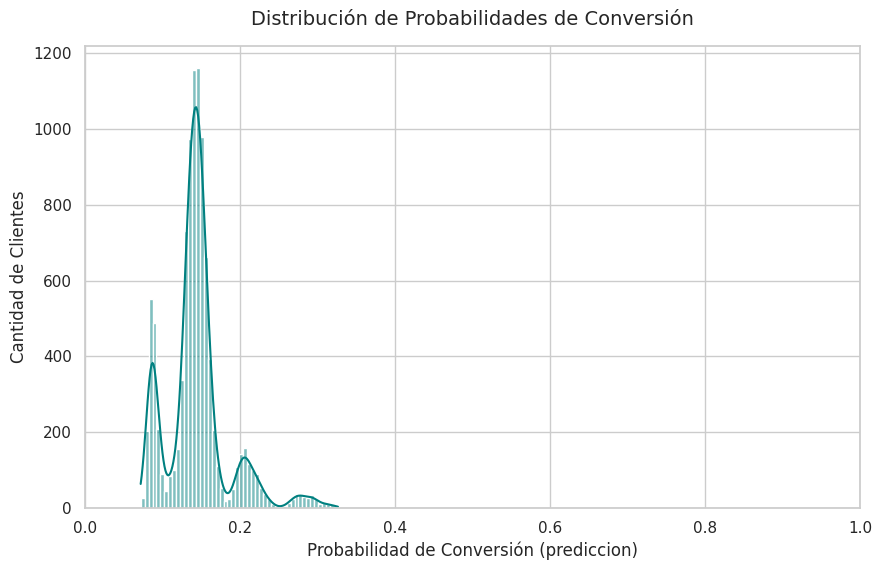

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the generated submission file
submission_path = '/content/drive/MyDrive/datafest/sample_submission.csv'
submission = pd.read_csv(submission_path)

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot the distribution of the 'prediccion' column
sns.histplot(submission['prediccion'], bins=50, kde=True, color='teal')

# Add labels and title
plt.title('Distribución de Probabilidades de Conversión', fontsize=14, pad=15)
plt.xlabel('Probabilidad de Conversión (prediccion)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Set x-axis limits between 0 and 1 since it is a probability
plt.xlim(0, 1)

# Display the plot
plt.show()